In [1]:
import os
import gc
import sys
import glob
import copy
import numpy as np
import pandas as pd
import netCDF4 as nc
from datetime import datetime, timedelta
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib import colors  
import matplotlib.ticker as mticker

In [2]:
# To use PLUMBER2_GPP_common_utils, change directory to where it exists
import importlib

# Change the working directory to where the script exists
os.chdir('/srv/ccrc/LandAP/z5218916/script/PLUMBER2/LSM_GPP_PLUMBER2')

# Import the module directly by name
from PLUMBER2_GPP_common_utils import *

# Now you can reload the module after any edits
# import PLUMBER2_GPP_common_utils
# importlib.reload(PLUMBER2_GPP_common_utils)

In [3]:
# Path of PLUMBER 2 dataset
PLUMBER2_path      = "/srv/ccrc/LandAP/z5218916/data/PLUMBER2/"
PLUMBER2_flux_path = "/srv/ccrc/LandAP/z5218916/data/Fluxnet_data/Post-processed_PLUMBER2_outputs/Nc_files/Flux/"
PLUMBER2_met_path  = "/srv/ccrc/LandAP/z5218916/data/Fluxnet_data/Post-processed_PLUMBER2_outputs/Nc_files/Met/"

site_names, IGBP_types, clim_types, model_names = load_default_list()

remove_site        = get_removed_site_names()

models_calc_LAI   = ['ORC2_r6593','ORC2_r6593_CO2','ORC3_r7245_NEE','ORC3_r8120','GFDL','SDGVM','QUINCY','NoahMPv401']
model_LAI_names   = {'ORC2_r6593':'lai','ORC2_r6593_CO2':'lai','ORC3_r7245_NEE':'lai','ORC3_r8120':'lai',
                     'GFDL':'lai', 'SDGVM':'lai','QUINCY':'LAI','NoahMPv401':'LAI'} #

# Calculate remaining sites
set_site_names      = set(site_names)
set_remove_site     = set(remove_site)
remain_sites        = set_site_names - set_remove_site
remain_sites        = list(remain_sites)

In [18]:
site_name     = 'US-PFa'
model_in      = 'obs'
var_name      = 'GPP'
var_name_orig = 'GPP'

if model_in == 'obs':
    PLUMBER2_orig_file = glob.glob(f"{PLUMBER2_flux_path}*{site_name}*.nc")
else:
    PLUMBER2_orig_file = glob.glob(f"/srv/ccrc/LandAP/z5218916/data/PLUMBER2/{model_in}/*{site_name}*.nc")

PLUMBER2_processe_file = f"/srv/ccrc/LandAP/z5218916/script/PLUMBER2/LSM_GPP_PLUMBER2/nc_files/{site_name}.nc"  # GPP, NEE

with nc.Dataset(PLUMBER2_processe_file) as f_processed:
    var_in    = f_processed.variables[model_in + '_' + var_name][:].data

    time       = nc.num2date(f_processed.variables['CABLE_time'][:],f_processed.variables['CABLE_time'].units,only_use_cftime_datetimes=False,only_use_python_datetimes=True)

time_intervals = np.diff(time)[0]/timedelta(seconds=3600)
day_tot_step   = int(24/time_intervals)

obs, US-PFa, has long gap (>100 days) of 364 days 23:00:00 between 1995-01-01 01:00:00 and 1996-01-01 00:00:00
1995-01-01 01:00:00 1996-01-01 00:00:00 8759.0


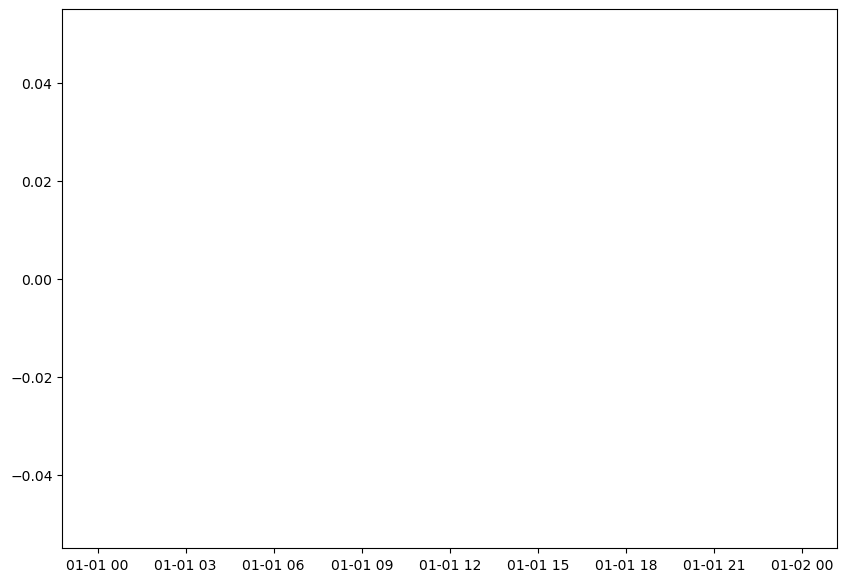

In [19]:
# Reading in
f      = nc.Dataset(f"{PLUMBER2_processe_file}",'r+')
var_in = f.variables[model_in + '_' + var_name][:].data
time   = nc.num2date(f.variables['CABLE_time'][:],f.variables['CABLE_time'].units,
                     only_use_cftime_datetimes=False,only_use_python_datetimes=True)

# Calculate time interval and total time steps in a day
time_intervals = np.diff(time)[0]/timedelta(seconds=3600)
day_tot_step   = int(24/time_intervals)

# Convert to Pandas Series with time as the index
var_in      = pd.Series(var_in, index=pd.to_datetime(time))
var_out     = copy.deepcopy(var_in)


if model_in == 'QUINCY':

    nan_indices   = np.where(np.isnan(var_out))[0]
    start_indices = []
    end_indices   = []

    # Find all leap years where 29th Feb exists
    for i, t in enumerate(time):
        # Find the index of the first 29th Feb (00:00) and the first 1st March (00:00) each leap year
        if t.year % 4 == 0 and t.month == 2 and t.day == 29 and t.hour == 0 and t.minute == 0:
            start_indices.append(i)
        elif t.year % 4 == 0 and t.month == 3 and t.day == 3 and t.hour == 1 and t.minute == 0:
            end_indices.append(i)
        
    # Pairing the start and end indices for each leap year
    leap_year_indices = list(zip(start_indices, end_indices))
    
    # Print the results
    for start, end in leap_year_indices:
        print(start,end)
        # Find the first index in nan_indices that is larger than 2000
        first_nan_after = next((idx for idx in nan_indices if idx >= start), None)
        last_nan_before = next((idx for idx in nan_indices[::-1] if idx <= end), None)
        var_in[first_nan_after:last_nan_before] = np.nan

# Identify gaps
gaps       = var_in.isna()

# Find start and end of gaps
gap_starts = var_in.index[gaps & ~gaps.shift(1, fill_value=False)]
gap_ends   = var_in.index[gaps & ~gaps.shift(-1, fill_value=False)]

# Calculate the lengths of gaps
gap_lengths = (gap_ends - gap_starts).total_seconds() / 3600  # Convert to hours

for start, end, gap_len in zip(gap_starts, gap_ends, gap_lengths):

    gap_duration = end - start

    if gap_len <= 3:  # Gaps shorter or equal to 3 hours (interpolate)
        # print('gap_len <= 3')
        one_step_before_start = var_in.index[var_in.index.get_loc(start) - 1]
        two_step_after_end    = var_in.index[var_in.index.get_loc(end) + 2]
        var_out[one_step_before_start:two_step_after_end] = \
              var_in[one_step_before_start:two_step_after_end].interpolate(method='linear')
        
    elif 3 < gap_len < 2400:  # Gaps longer than 3 hours
        # Find the closest intact 24-hour diurnal cycle before the gap
        prev_valid_cycle = None
        for days_back in range(1, 31):  # Search within a 30-day window
            try:
                temp = var_in.index.get_loc(start - pd.Timedelta(days=days_back))
                prev_day_range = var_in[temp:temp+day_tot_step]
                if not prev_day_range.isna().any() and len(prev_day_range) == day_tot_step:  # Check for intact 24-hour cycle
                    prev_valid_cycle = prev_day_range
                    break
            except:
                continue

        # Find the closest intact 24-hour diurnal cycle after the gap
        next_valid_cycle = None
        for days_forward in range(1, 31):  # Search within a 30-day window
            try:
                temp = var_in.index.get_loc(end + pd.Timedelta(days=days_forward - 1))
                next_day_range = var_in[temp:temp+day_tot_step]
                if not next_day_range.isna().any() and len(next_day_range) == day_tot_step:  # Check for intact 24-hour cycle
                    next_valid_cycle = next_day_range
                    break
            except:
                continue

        # Fill the gap
        start_loc = var_in.index.get_loc(start)
        end_loc   = var_in.index.get_loc(end)

        for ts in np.arange(start_loc,end_loc+1):
            
            time_of_day = var_in.index[ts].time()  # Extract the hour for the gap time
            prev_value  = prev_valid_cycle[prev_valid_cycle.index.time == time_of_day] if prev_valid_cycle is not None else pd.Series()
            next_value  = next_valid_cycle[next_valid_cycle.index.time == time_of_day] if next_valid_cycle is not None else pd.Series()

            if not prev_value.empty and not next_value.empty:
                # If both are found, take the average
                var_out[ts] = (prev_value.values[0] + next_value.values[0]) / 2
            elif not prev_value.empty:
                # If only the previous cycle is found
                var_out[ts] = prev_value.values[0]
            elif not next_value.empty:
                # If only the next cycle is found
                var_out[ts] = next_value.values[0]
    else:
        print(f"{model_in}, {site_name}, has long gap (>100 days) of {gap_duration} between {start} and {end}")

# # Add the soil moisture values to the output nc file
# try:
#     var = f.createVariable(f"{model_in}_{var_name}_gap_fill", 'f4', (model_in+'_time'))
# except:
#     var = f.createVariable(f"{model_in}_{var_name}_gap_fill", 'f4', ('CABLE_time'))
# var.standard_name = f"Gap filled {f.variables[f'{model_in}_{var_name}'].standard_name}"
# var.long_name     = f"Gap filled {f.variables[f'{model_in}_{var_name}'].long_name}"
# var.units         = f.variables[f"{model_in}_{var_name}"].units
# var[:]            = var_out

# try:
#     var_qc = f.createVariable(f"{model_in}_{var_name}_qc", 'f4', (model_in+'_time'))
# except:
#     var_qc = f.createVariable(f"{model_in}_{var_name}_qc", 'f4', ('CABLE_time'))
# var_qc.standard_name = f"Quality Control {f.variables[f'{model_in}_{var_name}'].standard_name}; 0: no gap-filling, 1: gap-filling"
# var_qc[:]            = np.where(np.isnan(var_in), 1, 0)
# f.close()


fig, ax  = plt.subplots(figsize=[10, 7])
for start, end, gap_len in zip(gap_starts, gap_ends, gap_lengths):
    print(start, end, gap_len)
    
    try:
        ts_s = var_in.index.get_loc(start - pd.Timedelta(days=2))
        ts_e = var_in.index.get_loc(end   + pd.Timedelta(days=2))
        sct  = ax.plot(var_in[ts_s:ts_e],  lw=2.0, color='red', ls='-',  alpha=0.4, label='no_gap_fill')
        sct  = ax.plot(var_out[ts_s:ts_e], lw=2.0, color='blue',ls=':', alpha=0.4, label='gap_fill')
    except:
        sct  = ax.plot(var_in[start:end],  lw=2.0, color='red', ls='-',  alpha=0.4, label='no_gap_fill')
        sct  = ax.plot(var_out[start:end], lw=2.0, color='blue',ls=':', alpha=0.4, label='gap_fill')
    
    # ax.legend(fontsize=8,frameon=False)

fig.savefig(f"./plots/check_gap_fill/gap_fill_{var_name}_{site_name}_{model_in}",bbox_inches='tight',dpi=300)


In [17]:
model_in = 'QUINCY'
PLUMBER2_processe_file = f"/srv/ccrc/LandAP/z5218916/script/PLUMBER2/LSM_GPP_PLUMBER2/nc_files/IT-Ren.nc"  # GPP, NEE
with nc.Dataset(PLUMBER2_processe_file) as f_processed:
    var_in = f_processed.variables[model_in + '_' + var_name][:].data
np.sum(np.isnan(var_in))


48

In [10]:
#### Convert to Pandas Series with time as the index
var_in     = pd.Series(var_in, index=pd.to_datetime(time))
var_out    = copy.deepcopy(var_in)

# Identify gaps
gaps       = var_in.isna()

# Find start and end of gaps
gap_starts = var_in.index[gaps & ~gaps.shift(1, fill_value=False)]
gap_ends   = var_in.index[gaps & ~gaps.shift(-1, fill_value=False)]

# Calculate the lengths of gaps
gap_lengths = (gap_ends - gap_starts).total_seconds() / 3600  # Convert to hours

for start, end, gap_len in zip(gap_starts, gap_ends, gap_lengths):
    
    # print('start',start,'end',end,'gap_len',gap_len)
    # >start 2003-12-04 00:00:00 end 2004-01-01 00:00:00 gap_len 672.0
    
    gap_duration = end - stat
    # print('gap_duration',gap_duration)
    # >gap_duration 28 days 00:00:00
    
    if gap_len <= 3:  # Gaps shorter or equal to 3 hours (interpolate)
        one_step_before_start = var_in.index[var_in.index.get_loc(start) - 1]
        two_step_after_end    = var_in.index[var_in.index.get_loc(end) + 2]
        var_out[one_step_before_start:two_step_after_end] = \
              var_in[one_step_before_start:two_step_after_end].interpolate(method='linear')

    elif gap_len > 3:  # Gaps longer than 3 hours
        # Find the closest intact 24-hour diurnal cycle before the gap
        prev_valid_cycle = None
        for days_back in range(1, 31):  # Search within a 30-day window
            temp = var_in.index.get_loc(start - pd.Timedelta(days=days_back))
            prev_day_range = var_in[temp:temp+day_tot_step]
            if not prev_day_range.isna().any() and len(prev_day_range) == day_tot_step:  # Check for intact 24-hour cycle
                prev_valid_cycle = prev_day_range
                break
                
        # Find the closest intact 24-hour diurnal cycle after the gap
        next_valid_cycle = None
        for days_forward in range(1, 31):  # Search within a 30-day window
            try:
                temp = var_in.index.get_loc(end + pd.Timedelta(days=days_forward - 1))
                next_day_range = var_in[temp:temp+day_tot_step]
                if not next_day_range.isna().any() and len(next_day_range) == day_tot_step:  # Check for intact 24-hour cycle
                    next_valid_cycle = next_day_range
                    break
            except:
                continue
        # Fill the gap
        start_loc = var_in.index.get_loc(start)
        end_loc   = var_in.index.get_loc(end)
        
        for ts in np.arange(start_loc,end_loc+1):
            time_of_day = var_in.index[ts].time()  # Extract the hour for the gap time
            
            prev_value  = prev_valid_cycle[prev_valid_cycle.index.time == time_of_day] if prev_valid_cycle is not None else pd.Series()
            next_value  = next_valid_cycle[next_valid_cycle.index.time == time_of_day] if next_valid_cycle is not None else pd.Series()

            if not prev_value.empty and not next_value.empty:
                # If both are found, take the average
                var_out[ts] = (prev_value.values[0] + next_value.values[0]) / 2
            elif not prev_value.empty:
                # If only the previous cycle is found
                var_out[ts] = prev_value.values[0]
            elif not next_value.empty:
                # If only the next cycle is found
                var_out[ts] = next_value.values[0]
                
            print(ts, time_of_day, var_out[ts])
    else:
        print(f"Long gap of {gap_duration} between {start} and {end}")


NameError: name 'stat' is not defined